In [ ]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="species")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=None, 
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", 
      classification_report(y_test, y_pred, target_names=iris.target_names))

new_sample = [[5.1, 3.5, 1.4, 0.2]]
pred_class_idx = rf_model.predict(new_sample)[0]
print(f"\nPrediction for sample {new_sample} => {iris.target_names[pred_class_idx]}")

Accuracy: 0.9

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30


Prediction for sample [[5.1, 3.5, 1.4, 0.2]] => setosa


c:\Users\KLH\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.9385964912280702

Classification Report:
               precision    recall  f1-score   support

   malignant       0.91      0.93      0.92        42
      benign       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



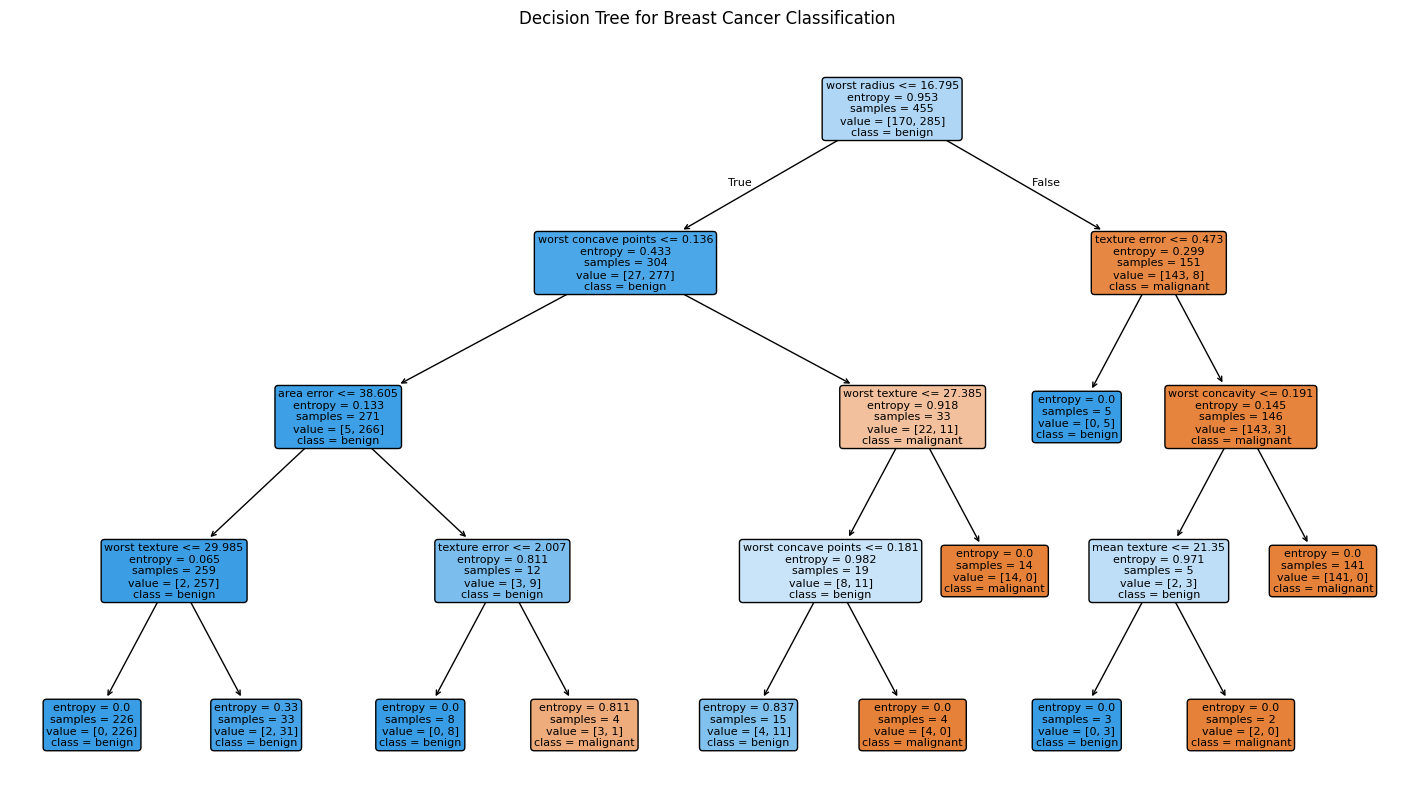


Prediction for first test sample => malignant


In [ ]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

data = load_breast_cancer()
X = pd.DataFrame(data=data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

dt_model = DecisionTreeClassifier(
    criterion="entropy", 
    max_depth=4, 
    random_state=42
)
dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", 
      classification_report(y_test, y_pred, target_names=data.target_names))

plt.figure(figsize=(18, 10))
plot_tree(
    dt_model, 
    feature_names=data.feature_names, 
    class_names=data.target_names, 
    filled=True, 
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree for Breast Cancer Classification")
plt.show()

sample = X_test.iloc[[0]]
pred_idx = dt_model.predict(sample)[0]
print(f"\nPrediction for first test sample => {data.target_names[pred_idx]}")